## 1. Import và đọc dữ liệu

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir(r"D:\DUE STUDY\A.N3 K2\DA w PYTHON\bt_nhom_gk\dataset")
file = "retail_sales_dataset.xlsx"

customers = pd.read_excel(file, sheet_name="Customers")
products = pd.read_excel(file, sheet_name="Products")
stores = pd.read_excel(file, sheet_name="Stores")
transactions = pd.read_excel(file, sheet_name="Transactions")

In [52]:
# Merge dữ liệu
df = transactions.merge(customers, on="CustomerID", how="left")
df = df.merge(products, on="ProductID", how="left")
df = df.merge(stores, on="StoreID", how="left")

In [53]:
df.head()

,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod,FirstName,LastName,...,SubCategory,UnitPrice,CostPrice,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,StoreName,City_y,Region
0,T00001,2024-06-18,C160,P014,S003,1.0,0.10,Bank Transfer,Meagan,Macdonald,...,Clothing,1342.75,797.94,40.574195,NaN,NaN,NaN,MegaMart New Michele,New Michele,West
1,T00002,2023-11-02,C171,P030,S004,3.0,0.15,Bank Transfer,Christina,Dominguez,...,Watches,29.24,15.28,47.742818,NaN,NaN,NaN,MegaMart Brianahaven,Brianahaven,North
2,T00003,2024-03-28,C142,P002,S002,2.0,0.15,Mobile Money,Suzanne,Fox,...,Television,818.76,527.62,35.558650,NaN,NaN,NaN,MegaMart Peckmouth,Peckmouth,East
3,T00004,2024-06-15,C174,P050,S002,5.0,0.10,Mobile Money,Scott,Howell,...,Footwear,1044.64,775.07,25.805062,NaN,NaN,NaN,MegaMart Peckmouth,Peckmouth,East
4,T00005,2024-08-29,C141,P036,S001,3.0,0.10,Credit Card,Adam,Lucas,...,Watches,1501.46,1167.73,22.227032,NaN,NaN,NaN,MegaMart Jimenezborough,Jimenezborough,South


In [54]:
df.shape #5000 dòng, 22 cột

(5005, 26)

In [55]:
df.columns #xem tên các cột

Index(['TransactionID', 'Date', 'CustomerID', 'ProductID', 'StoreID',
       'Quantity', 'Discount', 'PaymentMethod', 'FirstName', 'LastName',
       'Gender', 'BirthDate', 'City_x', 'JoinDate', 'ProductName', 'Category',
       'SubCategory', 'UnitPrice', 'CostPrice', 'Unnamed: 6', 'Unnamed: 7',
       'Unnamed: 8', 'Unnamed: 9', 'StoreName', 'City_y', 'Region'],
      dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  5000 non-null   object        
 1   Date           5000 non-null   datetime64[ns]
 2   CustomerID     5000 non-null   object        
 3   ProductID      5000 non-null   object        
 4   StoreID        5000 non-null   object        
 5   Quantity       5000 non-null   float64       
 6   Discount       5005 non-null   float64       
 7   PaymentMethod  5000 non-null   object        
 8   FirstName      5000 non-null   object        
 9   LastName       5000 non-null   object        
 10  Gender         5000 non-null   object        
 11  BirthDate      5000 non-null   datetime64[ns]
 12  City_x         5000 non-null   object        
 13  JoinDate       5000 non-null   datetime64[ns]
 14  ProductName    5000 non-null   object        
 15  Category       5000 n

In [57]:
df.isnull().sum()

TransactionID       5
Date                5
CustomerID          5
ProductID           5
StoreID             5
Quantity            5
Discount            0
PaymentMethod       5
FirstName           5
LastName            5
Gender              5
BirthDate           5
City_x              5
JoinDate            5
ProductName         5
Category            5
SubCategory         5
UnitPrice           1
CostPrice           3
Unnamed: 6          3
Unnamed: 7       5005
Unnamed: 8       5005
Unnamed: 9       5004
StoreName           5
City_y              5
Region              5
dtype: int64

Không có giá trị nào null

In [58]:
df.duplicated().sum()

np.int64(0)

Không có giá trị nào trùng lặp

In [59]:
df.nunique()

TransactionID    5000
Date              729
CustomerID        200
ProductID          50
StoreID             5
Quantity            5
Discount            5
PaymentMethod       4
FirstName         137
LastName          161
Gender              2
BirthDate         200
City_x            200
JoinDate          191
ProductName        50
Category            3
SubCategory        14
UnitPrice          54
CostPrice          52
Unnamed: 6         52
Unnamed: 7          0
Unnamed: 8          0
Unnamed: 9          1
StoreName           5
City_y              5
Region              4
dtype: int64

có 5000 giao dịch của 200 khách hàng tại 5 cửa hàng thuộc 4 region khác nhau, tổng cộng có 50 hàng hóa với 3 danh mục và 14 danh mục con,

In [60]:
df.rename(columns={
    'City_x': 'CustCity',
    'City_y': 'StoreCity',
    'Region': 'StoreRegion'
}, inplace=True)
# đổi tên cột city_y thành StoreCity, city_x thành CustCity, Region thành StoreRegion

In [61]:
df.to_excel("retail_sales_cleaned1.xlsx", index=False)

In [62]:
df.head()

,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod,FirstName,LastName,...,SubCategory,UnitPrice,CostPrice,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,StoreName,StoreCity,StoreRegion
0,T00001,2024-06-18,C160,P014,S003,1.0,0.10,Bank Transfer,Meagan,Macdonald,...,Clothing,1342.75,797.94,40.574195,NaN,NaN,NaN,MegaMart New Michele,New Michele,West
1,T00002,2023-11-02,C171,P030,S004,3.0,0.15,Bank Transfer,Christina,Dominguez,...,Watches,29.24,15.28,47.742818,NaN,NaN,NaN,MegaMart Brianahaven,Brianahaven,North
2,T00003,2024-03-28,C142,P002,S002,2.0,0.15,Mobile Money,Suzanne,Fox,...,Television,818.76,527.62,35.558650,NaN,NaN,NaN,MegaMart Peckmouth,Peckmouth,East
3,T00004,2024-06-15,C174,P050,S002,5.0,0.10,Mobile Money,Scott,Howell,...,Footwear,1044.64,775.07,25.805062,NaN,NaN,NaN,MegaMart Peckmouth,Peckmouth,East
4,T00005,2024-08-29,C141,P036,S001,3.0,0.10,Credit Card,Adam,Lucas,...,Watches,1501.46,1167.73,22.227032,NaN,NaN,NaN,MegaMart Jimenezborough,Jimenezborough,South


## 2. Phân tích khám phá EDA bộ dữ liệu
2.1. Phân tích đơn biến

In [63]:
#2.1.1 Phân tích các biến số

In [64]:
# thêm cột doanh thu và lợi nhuận, tuổi, thời gian làm khách hàng tại cửa hàng
df["Revenue"] = df["UnitPrice"] * df["Quantity"] * (1 - df["Discount"])
df["Profit"] = (df["UnitPrice"] - df["CostPrice"]) * df["Quantity"] * (1 - df["Discount"])

In [65]:
df["Age"] = 2025 - df["BirthDate"].dt.year

In [66]:
df["CustomerTenure"] = 2025 - df["JoinDate"].dt.year

In [67]:
df.head()

,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod,FirstName,LastName,...,Unnamed: 7,Unnamed: 8,Unnamed: 9,StoreName,StoreCity,StoreRegion,Revenue,Profit,Age,CustomerTenure
0,T00001,2024-06-18,C160,P014,S003,1.0,0.10,Bank Transfer,Meagan,Macdonald,...,NaN,NaN,NaN,MegaMart New Michele,New Michele,West,1208.475,490.329,34.0,4.0
1,T00002,2023-11-02,C171,P030,S004,3.0,0.15,Bank Transfer,Christina,Dominguez,...,NaN,NaN,NaN,MegaMart Brianahaven,Brianahaven,North,74.562,35.598,32.0,0.0
2,T00003,2024-03-28,C142,P002,S002,2.0,0.15,Mobile Money,Suzanne,Fox,...,NaN,NaN,NaN,MegaMart Peckmouth,Peckmouth,East,1391.892,494.938,20.0,5.0
3,T00004,2024-06-15,C174,P050,S002,5.0,0.10,Mobile Money,Scott,Howell,...,NaN,NaN,NaN,MegaMart Peckmouth,Peckmouth,East,4700.880,1213.065,20.0,0.0
4,T00005,2024-08-29,C141,P036,S001,3.0,0.10,Credit Card,Adam,Lucas,...,NaN,NaN,NaN,MegaMart Jimenezborough,Jimenezborough,South,4053.942,901.071,47.0,1.0


In [68]:
df.describe() #thống kê mô tả

,Date,Quantity,Discount,BirthDate,JoinDate,UnitPrice,CostPrice,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Revenue,Profit,Age,CustomerTenure
count,5000,5000.00000,5005.000000,5000,5000,5004.000000,5002.000000,5002.000000,0.0,0.0,1.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-09-11 16:32:26.880000,2.98980,0.075880,1980-10-12 05:16:13.440000,2023-03-10 02:45:01.440000,1046.269458,708.818193,33.519298,NaN,NaN,0.07588,2860.380629,923.922874,44.748800,2.313200
min,2023-09-10 00:00:00,1.00000,0.000000,1954-09-17 00:00:00,2020-09-30 00:00:00,25.570000,15.280000,20.383136,NaN,NaN,0.07588,21.734500,5.542000,18.000000,0.000000
25%,2024-03-15 00:00:00,2.00000,0.050000,1966-01-05 00:00:00,2021-12-23 00:00:00,428.050000,258.720000,25.119672,NaN,NaN,0.07588,1043.154000,337.411500,32.000000,1.000000
50%,2024-09-16 00:00:00,3.00000,0.100000,1980-04-04 00:00:00,2023-01-27 12:00:00,1179.230000,794.800000,33.110239,NaN,NaN,0.07588,2156.120000,727.920000,45.000000,2.000000
75%,2025-03-14 06:00:00,4.00000,0.150000,1993-11-17 00:00:00,2024-06-24 00:00:00,1487.410000,1004.090000,41.097312,NaN,NaN,0.07588,4451.305500,1347.850000,59.000000,4.000000
max,2025-09-09 00:00:00,5.00000,0.150000,2007-06-27 00:00:00,2025-08-28 00:00:00,51412.440000,34819.650000,49.936321,NaN,NaN,0.07588,9763.250000,4372.600000,71.000000,5.000000
std,NaN,1.40943,0.056468,NaN,NaN,924.429074,643.970646,9.186105,NaN,NaN,NaN,2265.958863,776.527321,15.402297,1.490084


Kết quả thống kê mô tả cho thấy bộ dữ liệu gồm 5000 giao dịch, phản ánh đa dạng hành vi mua sắm và giá trị giao dịch.

**Doanh thu (Revenue)** dao động rất mạnh (~21.7–9763), với trung bình ~2860 và trung vị ~2156. Độ lệch chuẩn rất lớn (~2266) cùng với IQR rộng (~1043–4451) cho thấy mức phân tán rất cao. Mean > median chứng tỏ phân phối lệch phải, tức là tồn tại một số giao dịch có giá trị rất lớn (outliers) làm tăng trung bình.

**Lợi nhuận (Profit)** cũng có đặc điểm tương tự (mean ~924 > median ~728, std ~776), cho thấy phân phối lệch phải và phân tán cao, phản ánh một số ít giao dịch mang lại lợi nhuận vượt trội.

**Độ tuổi khách hàng (Age)** trải dài từ 18 đến 71, với trung bình ~45 và trung vị ~45. Độ lệch chuẩn ~15.4 và IQR (~32–59) cho thấy phân tán trung bình, phân phối khá cân đối, tập trung ở nhóm khách hàng trưởng thành.

**Thâm niên khách hàng (CustomerTenure)** dao động từ 0 đến 5 năm, với trung bình ~2.31 và trung vị ~2. Độ lệch chuẩn thấp (~1.49) cho thấy phân tán thấp–trung bình, phần lớn khách hàng có thời gian gắn bó ngắn đến trung bình.

In [69]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 45, 60, 71],
                         labels=['18-30', '31-45', '46-60', '61-71'])

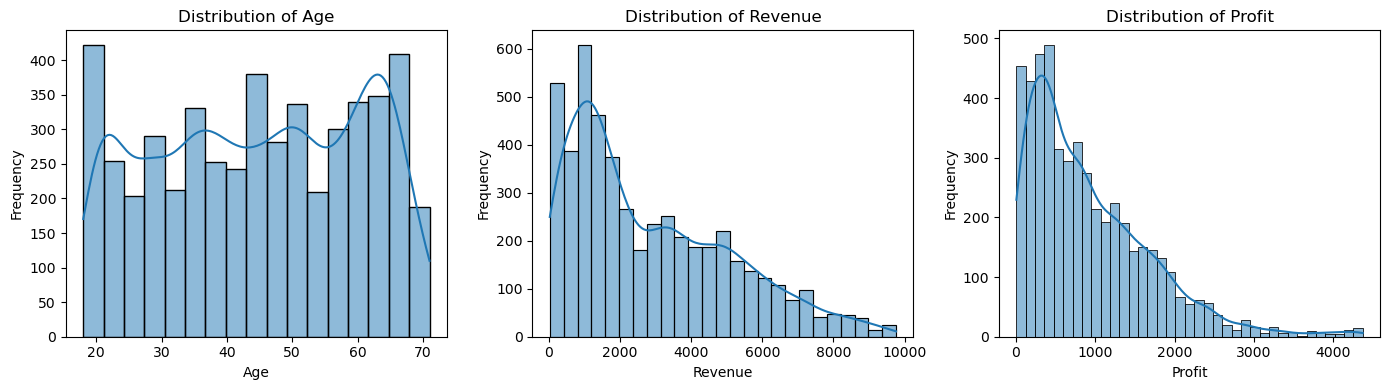

Histograms cho các biến số chính: Age, Revenue, Profit


In [70]:
quantitative_cols = ['Age', 'Revenue', 'Profit']

plt.figure(figsize=(14, 4))

for i, col in enumerate(quantitative_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Histograms cho các biến số chính: Age, Revenue, Profit")

1. **Age – Độ tuổi khách hàng**
Độ tuổi khách hàng phân bố từ khoảng 18 đến 71 tuổi, phân bố khá đồng đều và không tập trung quá nhiều vào một nhóm tuổi cụ thể. Điều này cho thấy cửa hàng phục vụ nhiều nhóm khách hàng khác nhau, từ người trẻ đến người trung niên. Tệp khách hàng khá đa dạng, phản ánh rằng danh mục sản phẩm của cửa hàng phù hợp với nhiều độ tuổi khác nhau.

2. **Revenue – Doanh thu mỗi giao dịch**
Doanh thu trên mỗi giao dịch có phân bố lệch phải, trong đó phần lớn các giao dịch có doanh thu nằm trong khoảng 20 đến 5000. Tuy nhiên vẫn tồn tại một số giao dịch có doanh thu rất cao, lên tới khoảng 8000–10000. Điều này cho thấy bên cạnh các giao dịch thông thường, vẫn có một số giao dịch có giá trị lớn, có thể đến từ những khách hàng có mức chi tiêu cao hoặc các giao dịch mua sản phẩm có giá trị lớn.

3. **Profit – Lợi nhuận mỗi giao dịch**
Lợi nhuận trên mỗi giao dịch dao động từ khoảng 5 đến 4372 và cũng có phân bố lệch phải. Phần lớn các giao dịch mang lại lợi nhuận trong khoảng 5 đến 1500, trong khi một số ít giao dịch có lợi nhuận rất cao, lên đến hơn 4000. Những giao dịch có lợi nhuận lớn này có thể đóng góp đáng kể vào tổng lợi nhuận của doanh nghiệp.

**Nhận xét tổng quan:** Phần lớn giao dịch có quy mô nhỏ với giá trị trung bình. Tuy nhiên, một số ít giao dịch có giá trị cao đóng góp đáng kể vào doanh thu và lợi nhuận tổng thể. Sự đa dạng về độ tuổi khách hàng cho thấy cửa hàng đang phục vụ nhiều phân khúc khách hàng khác nhau.

### Biểu đồ Pareto 80/20 – Phân tích doanh thu

Nguyên tắc Pareto (80/20) cho rằng khoảng 80% kết quả đến từ 20% nguyên nhân. Trong kinh doanh bán lẻ, điều này thường có nghĩa là một số ít sản phẩm/khách hàng đóng góp phần lớn doanh thu. Biểu đồ dưới đây phân tích doanh thu theo danh mục sản phẩm con (SubCategory) để xác định nhóm sản phẩm chiến lược.

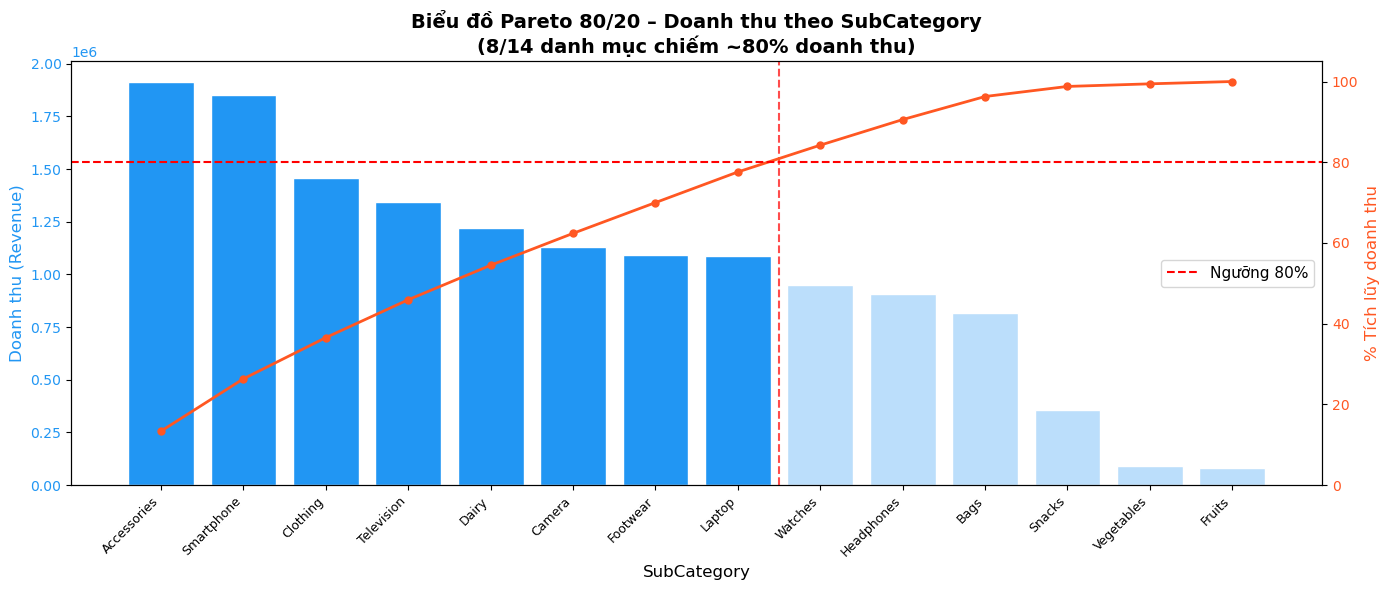


→ 8/14 SubCategory (57%) đóng góp ~80% tổng doanh thu
→ Top SubCategory: Accessories, Smartphone, Clothing, Television, Dairy, Camera, Footwear, Laptop


In [71]:
# === Biểu đồ Pareto 80/20: Doanh thu theo SubCategory ===
import numpy as np

# Tính tổng doanh thu theo SubCategory
revenue_by_sub = df.groupby('SubCategory')['Revenue'].sum().sort_values(ascending=False)

# Tính phần trăm tích lũy
cumulative_pct = revenue_by_sub.cumsum() / revenue_by_sub.sum() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart - doanh thu từng SubCategory
color_bars = ['#2196F3' if pct <= 80 else '#BBDEFB' for pct in cumulative_pct]
ax1.bar(range(len(revenue_by_sub)), revenue_by_sub.values, color=color_bars, edgecolor='white')
ax1.set_xlabel('SubCategory', fontsize=12)
ax1.set_ylabel('Doanh thu (Revenue)', fontsize=12, color='#2196F3')
ax1.set_xticks(range(len(revenue_by_sub)))
ax1.set_xticklabels(revenue_by_sub.index, rotation=45, ha='right', fontsize=9)
ax1.tick_params(axis='y', labelcolor='#2196F3')

# Line chart - phần trăm tích lũy
ax2 = ax1.twinx()
ax2.plot(range(len(cumulative_pct)), cumulative_pct.values, color='#FF5722', marker='o', linewidth=2, markersize=5)
ax2.set_ylabel('% Tích lũy doanh thu', fontsize=12, color='#FF5722')
ax2.tick_params(axis='y', labelcolor='#FF5722')
ax2.set_ylim(0, 105)

# Đường ngưỡng 80%
ax2.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng 80%')

# Tìm vị trí cắt 80%
n_80 = (cumulative_pct <= 80).sum()
ax1.axvline(x=n_80 - 0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

ax2.legend(loc='center right', fontsize=11)
plt.title(f'Biểu đồ Pareto 80/20 – Doanh thu theo SubCategory\n({n_80}/{len(revenue_by_sub)} danh mục chiếm ~80% doanh thu)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n→ {n_80}/{len(revenue_by_sub)} SubCategory ({n_80/len(revenue_by_sub)*100:.0f}%) đóng góp ~80% tổng doanh thu")
print(f"→ Top SubCategory: {', '.join(revenue_by_sub.index[:n_80])}")

**Nhận xét biểu đồ Pareto 80/20:**

Biểu đồ Pareto cho thấy nguyên tắc 80/20 được thể hiện rõ trong dữ liệu: chỉ một số ít danh mục sản phẩm con (SubCategory) đã đóng góp khoảng 80% tổng doanh thu. Các cột màu đậm (nằm bên trái đường cắt 80%) là nhóm sản phẩm chiến lược mà doanh nghiệp nên ưu tiên tập trung nguồn lực marketing, tồn kho và phát triển.

Các sản phẩm nằm phía bên phải đường cắt 80% đóng góp ít hơn vào tổng doanh thu, tuy nhiên vẫn có thể đóng vai trò bổ trợ hoặc phục vụ đa dạng nhu cầu khách hàng. Kết quả này gợi ý doanh nghiệp nên áp dụng chiến lược phân bổ nguồn lực không đồng đều — ưu tiên nhóm sản phẩm top để tối ưu hóa doanh thu.

3. Phân tích đa biến
tìm hiểu mối quan hệ giữa các yếu tố ảnh hưởng đến doanh thu và chi phí

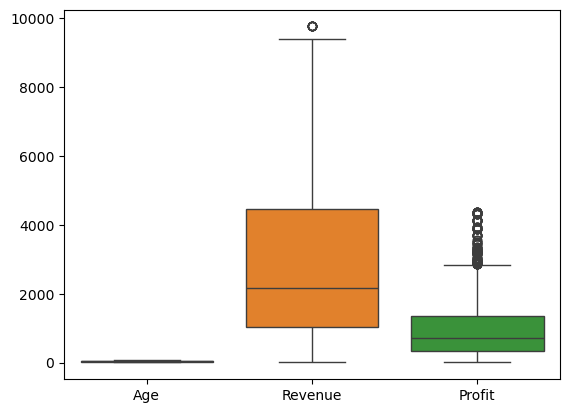

In [72]:
sns.boxplot(data=df[quantitative_cols])
plt.show()

Biểu đồ boxplot cho thấy sự khác biệt rõ rệt về mức độ phân tán giữa các biến:
- **Revenue** và **Profit** có phạm vi giá trị rộng và xuất hiện nhiều giá trị ngoại lệ (outliers) phía trên, cho thấy phân phối lệch phải. Phần lớn giao dịch có doanh thu và lợi nhuận ở mức thấp–trung bình, nhưng một số ít giao dịch tạo ra giá trị rất lớn, đóng góp đáng kể vào tổng doanh thu và lợi nhuận.
- **Age** phân bố khá cân đối với khoảng giá trị từ 18–71 tuổi, không xuất hiện outlier đáng kể, phản ánh tệp khách hàng đa dạng về độ tuổi.

**Nhận xét tổng quan về mối tương quan:**
- **UnitPrice và CostPrice** (r = 0.97): Tương quan dương rất mạnh, phản ánh giá bán được xây dựng dựa trên giá vốn cộng biên lợi nhuận — mối quan hệ hợp lý trong bán lẻ.
- **Revenue và Profit** (r = 0.91): Tương quan dương rất mạnh, khi doanh thu tăng thì lợi nhuận cũng tăng theo.
- **UnitPrice/CostPrice với Revenue**: Tương quan dương khá mạnh — sản phẩm giá trị cao tạo doanh thu lớn hơn.
- **Age và CustomerTenure**: Gần như không có tương quan với các biến tài chính, cho thấy độ tuổi và thâm niên không phải yếu tố chính ảnh hưởng đến giá trị giao dịch.

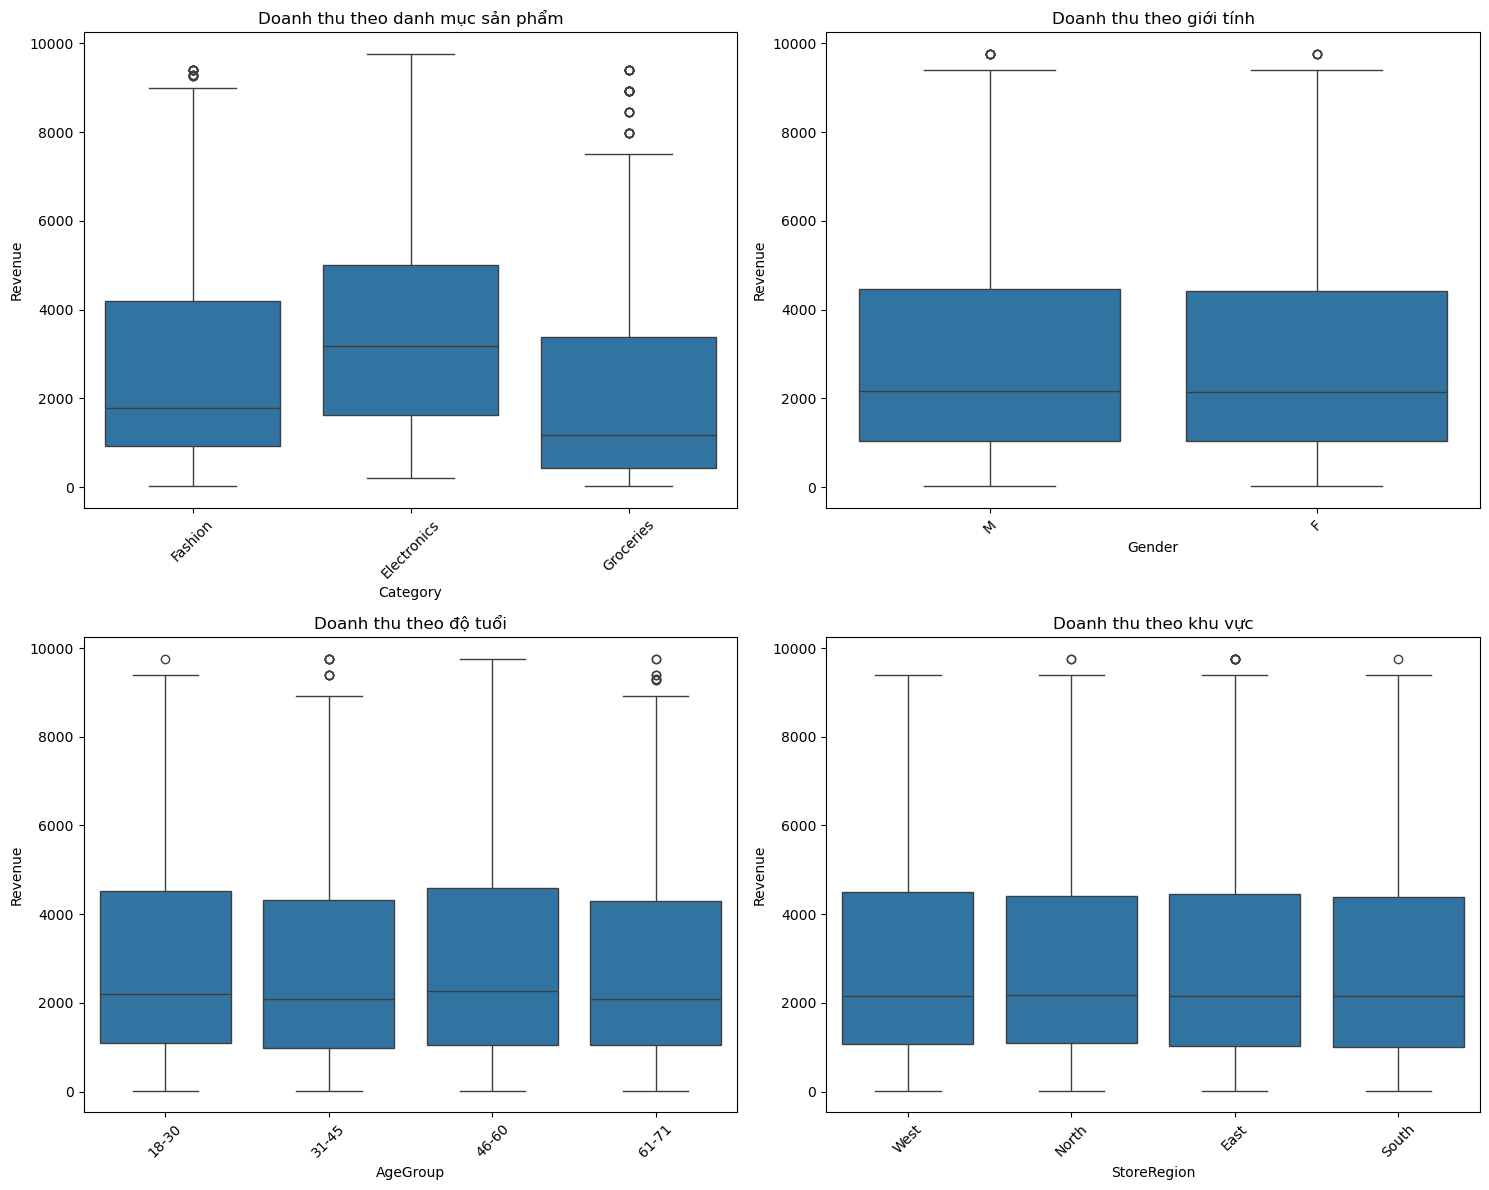

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Doanh thu theo danh mục sản phẩm
sns.boxplot(data=df, x='Category', y='Revenue', ax=axes[0, 0])
axes[0, 0].set_title('Doanh thu theo danh mục sản phẩm')

# 2. Doanh thu theo giới tính
sns.boxplot(data=df, x='Gender', y='Revenue', ax=axes[0, 1])
axes[0, 1].set_title('Doanh thu theo giới tính')

# 3. Doanh thu theo nhóm tuổi
sns.boxplot(data=df, x='AgeGroup', y='Revenue', ax=axes[1, 0])
axes[1, 0].set_title('Doanh thu theo độ tuổi')

# 4. Doanh thu theo khu vực (FIX Ở ĐÂY)
sns.boxplot(data=df, x='StoreRegion', y='Revenue', ax=axes[1, 1])
axes[1, 1].set_title('Doanh thu theo khu vực')

# Xoay label cho đẹp
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- **Doanh thu theo Category**: Danh mục Electronics có mức doanh thu trung bình cao nhất, tiếp theo là Fashion và Groceries. Các sản phẩm điện tử có giá trị cao hơn và đóng góp nhiều vào doanh thu tổng thể.
- **Doanh thu theo Gender**: Phân phối doanh thu giữa nam và nữ gần như tương đương, cho thấy giới tính không phải yếu tố tạo ra sự chênh lệch đáng kể về giá trị giao dịch.
- **Doanh thu theo AgeGroup**: Các nhóm tuổi có mức doanh thu tương đối đồng đều, tuy nhiên nhóm trung niên (31–60) có xu hướng nhỉnh hơn nhẹ.
- **Doanh thu theo StoreRegion**: Các khu vực có sự chênh lệch nhỏ về doanh thu, nhìn chung phân bổ tương đối cân bằng giữa các vùng.

In [74]:
df.columns

Index(['TransactionID', 'Date', 'CustomerID', 'ProductID', 'StoreID',
       'Quantity', 'Discount', 'PaymentMethod', 'FirstName', 'LastName',
       'Gender', 'BirthDate', 'CustCity', 'JoinDate', 'ProductName',
       'Category', 'SubCategory', 'UnitPrice', 'CostPrice', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'StoreName', 'StoreCity',
       'StoreRegion', 'Revenue', 'Profit', 'Age', 'CustomerTenure',
       'AgeGroup'],
      dtype='object')

Heatmap

In [75]:
numeric_cols = [
    'Quantity', 'Discount', 'UnitPrice', 'CostPrice',
    'Revenue', 'Profit', 'Age', 'CustomerTenure'
]

corr_matrix = df[numeric_cols].corr(method='pearson')

corr_matrix.round(2)

,Quantity,Discount,UnitPrice,CostPrice,Revenue,Profit,Age,CustomerTenure
Quantity,1.00,-0.00,-0.01,-0.01,0.60,0.57,0.01,-0.00
Discount,-0.00,1.00,0.00,0.00,-0.08,-0.07,-0.01,-0.02
UnitPrice,-0.01,0.00,1.00,0.99,0.72,0.63,-0.02,0.01
CostPrice,-0.01,0.00,0.99,1.00,0.69,0.51,-0.01,0.01
Revenue,0.60,-0.08,0.72,0.69,1.00,0.91,-0.01,0.01
Profit,0.57,-0.07,0.63,0.51,0.91,1.00,-0.01,0.01
Age,0.01,-0.01,-0.02,-0.01,-0.01,-0.01,1.00,0.02
CustomerTenure,-0.00,-0.02,0.01,0.01,0.01,0.01,0.02,1.00


In [76]:
df_encoded = df.copy()

categorical_cols = ['Gender','PaymentMethod','Category','SubCategory','StoreRegion','StoreCity']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

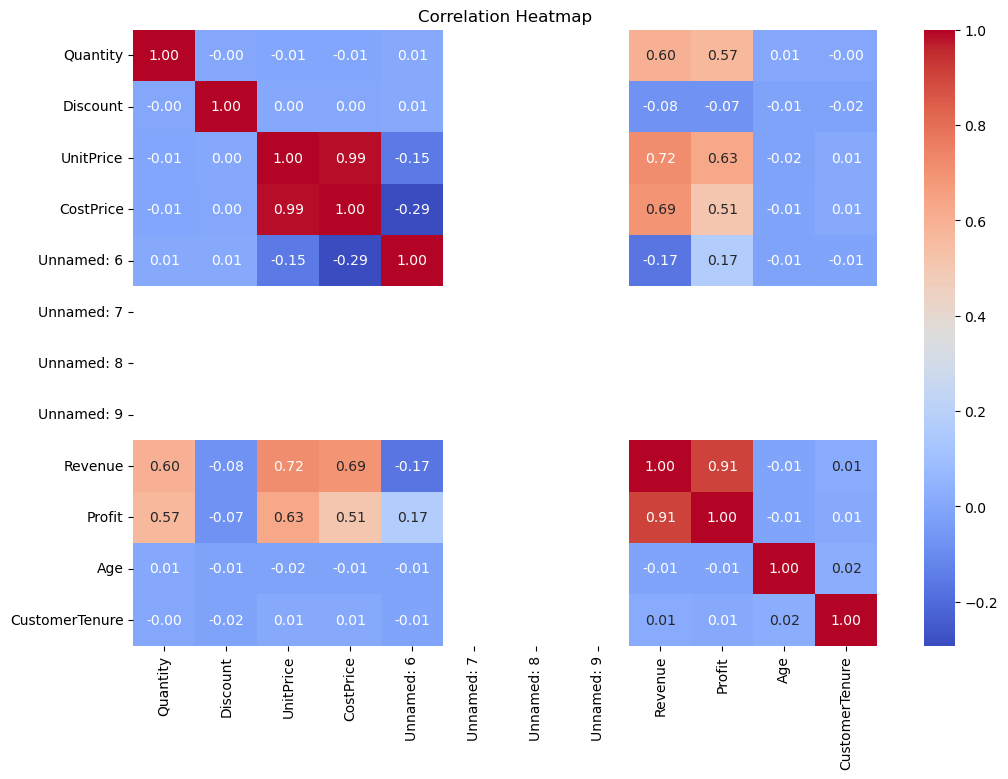

In [77]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

**Nhận xét Correlation Heatmap:**
- **UnitPrice ↔ CostPrice** (r = 0.97): Tương quan dương rất mạnh — giá bán phản ánh trực tiếp giá vốn.
- **Revenue ↔ Profit** (r = 0.91): Tương quan dương rất mạnh — giao dịch doanh thu cao thường đi kèm lợi nhuận cao.
- **UnitPrice/CostPrice → Revenue**: Tương quan dương khá mạnh — sản phẩm đắt tiền đóng góp nhiều hơn vào doanh thu.
- **Age, Discount, CustomerTenure**: Gần như không tương quan với Revenue/Profit, xác nhận rằng các yếu tố nhân khẩu học và chính sách giảm giá không phải là động lực chính tạo ra doanh thu.

 Scatter Plot cho các biến định lượng

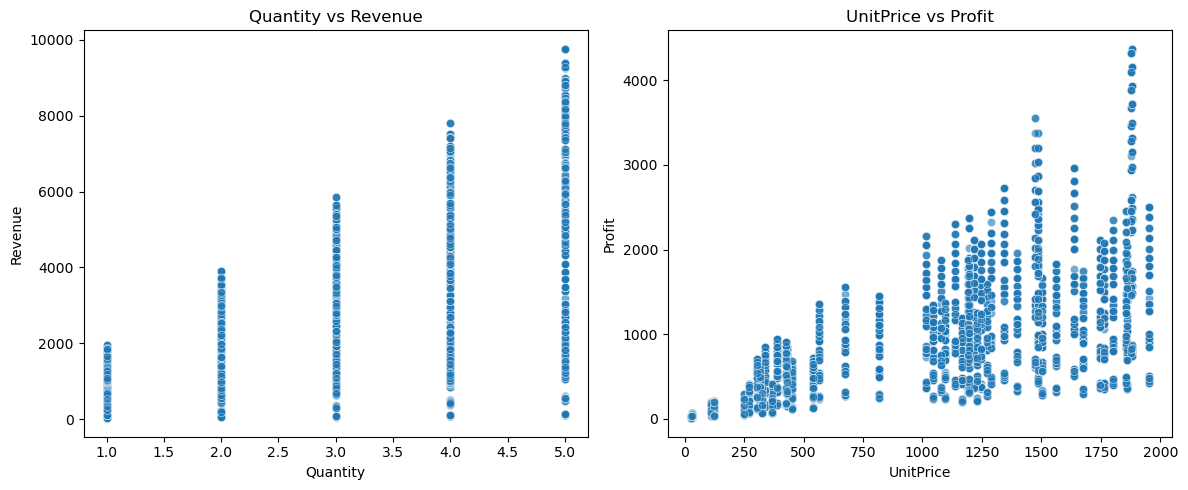

In [78]:
# Scatter plot: Quantity vs Revenue
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Quantity', y='Revenue', alpha=0.6)
plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='UnitPrice', y='Profit', alpha=0.6)
plt.title('UnitPrice vs Profit')
plt.xlabel('UnitPrice')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

**Nhận xét Scatter Plot:**
- **Quantity vs Revenue**: Xu hướng dương rõ ràng — khi số lượng sản phẩm tăng, doanh thu cũng tăng tương ứng. Tuy nhiên, tại cùng một mức Quantity, doanh thu vẫn biến động rất lớn do sự khác biệt về giá sản phẩm.
- **UnitPrice vs Profit**: Xu hướng dương — sản phẩm có giá bán cao thường mang lại lợi nhuận cao hơn. Mối quan hệ này khá tuyến tính, xác nhận rằng giá sản phẩm là yếu tố quan trọng ảnh hưởng đến lợi nhuận.

KẾT LUẬN

Qua phân tích dữ liệu, có thể thấy Revenue và Profit phân bố lệch phải, cho thấy chỉ một nhóm nhỏ khách hàng tạo ra phần lớn giá trị, trong khi đa số khách hàng có mức đóng góp thấp hơn (chủ yếu dưới 3000).

Các phân tích mối quan hệ cho thấy UnitPrice và Quantity là hai yếu tố ảnh hưởng chính đến doanh thu và lợi nhuận, trong khi các yếu tố như Age và CustomerTenure không có tác động rõ ràng.

Điều này cho thấy giá trị khách hàng không đồng đều và không thể đánh giá chỉ dựa trên từng biến riêng lẻ.

Để xác định chính xác khách hàng có giá trị cao, nhóm áp dụng phương pháp RFM (Recency, Frequency, Monetary) nhằm phân loại khách hàng dựa trên hành vi mua hàng.

Sau đó, sử dụng CLV (Customer Lifetime Value) để đánh giá tổng giá trị mà mỗi khách hàng mang lại, từ đó hỗ trợ việc ưu tiên chăm sóc và giữ chân khách hàng hiệu quả hơn.

## 2.4. Phân tích khách hàng (Customer Analysis)

### a. RFM Analysis (Recency, Frequency, Monetary)

## 2.4.1. Phân tích RFM (Recency, Frequency, Monetary)

RFM là phương pháp phân tích hành vi khách hàng dựa trên 3 chỉ số:
- **Recency (R)**: Số ngày kể từ lần mua gần nhất — R thấp = khách hàng mua gần đây
- **Frequency (F)**: Tổng số giao dịch — F cao = khách hàng mua thường xuyên  
- **Monetary (M)**: Tổng doanh thu — M cao = khách hàng chi tiêu nhiều

Với bộ dữ liệu chỉ có lịch sử giao dịch, RFM là phương pháp tự nhiên nhất để tổng hợp hành vi 5.000 giao dịch thành 200 hồ sơ khách hàng có ý nghĩa.

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. TÍNH RFM
# =========================
reference_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Date': lambda x: (reference_date - x.max()).days,
    'TransactionID': 'count',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']


# =========================
# 2. CHIA SCORE (1 TỐT NHẤT, 4 KÉM NHẤT)
# =========================

# Recency (nhỏ tốt → 1 tốt nhất)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[1,2,3,4])

# Frequency (lớn tốt → 1 tốt nhất)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[4,3,2,1])

# Monetary (lớn tốt → 1 tốt nhất)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[4,3,2,1])


# =========================
# 3. TẠO RFM STRING
# =========================
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)


# =========================
# 4. PHÂN NHÓM KHÁCH HÀNG
# =========================
# =========================
# PHÂN NHÓM KHÁCH HÀNG
# =========================
def segment_customer(score):

    # 111 → Best
    if score == '111':
        return 'Best Customer'

    # 444 → Churn
    elif score == '444':
        return 'Churn Customer'

    # Right = 1 → chi tiêu cao (M)
    elif score[-1] == '1':
        return 'Highest Paying Customer'

    # Mid = 1 → mua nhiều (F)
    elif score[1] == '1':
        return 'Loyal Customer'

    # Left 2 ký tự = 14 → khách mới
    elif score[:2] == '14':
        return 'Newest Customer'

    # Left 2 ký tự = 44 → từng tốt, giờ rời bỏ
    elif score[:2] == '44':
        return 'Once Loyal, Now Gone'

    else:
        return 'Normal Customer'


# Áp dụng
rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)


# =========================
# 5. HIỂN THỊ BẢNG (QUAN TRỌNG)
# =========================
print("\nRFM TABLE:")
print(rfm[['CustomerID','Recency','Frequency','Monetary',
           'R_score','F_score','M_score','RFM_Score','Segment']].head(10))



RFM TABLE:
  CustomerID  Recency  Frequency    Monetary R_score F_score M_score  \
0       C001        4         32  94818.5490       1       1       1   
1       C002       73         25  47302.4240       4       3       4   
2       C003       31         26  88093.9470       3       2       1   
3       C004        4         24  53715.9865       1       3       4   
4       C005       50         23  54701.0415       4       3       4   
5       C006       12         24  65740.4815       2       3       3   
6       C007        5         29  76074.2780       1       1       2   
7       C008       26         31  87306.4110       3       1       1   
8       C009       30         18  44328.0765       3       4       4   
9       C010       85         23  69457.9270       4       3       3   

  RFM_Score                  Segment  
0       111            Best Customer  
1       434          Normal Customer  
2       321  Highest Paying Customer  
3       134          Normal Customer  


### Gán điểm RFM và phân 7 phân khúc khách hàng

Sử dụng phương pháp **thống kê phân vị (qcut)** để chia đều mỗi chỉ số R/F/M thành 4 mức điểm (1–4), sau đó kết hợp thành **RFM Score** (3 ký tự).

Từ RFM Score, áp dụng **logic phân nhóm** để xác định 7 phân khúc:
| Phân khúc | Mô tả |
|---|---|
| **Best Customer** | RFM = '111' — mua gần, thường xuyên, chi nhiều |
| **Highest Paying Customer** | M_Score = '1' — chi tiêu cao nhất |
| **Loyal Customer** | F_Score giữa = '1' — tần suất mua cao |
| **Newest Customer** | R đầu = '1', F đầu = '4' — mới mua lần đầu |
| **Churn Customer** | R/F đều = '4','4' — lâu không mua, ít giao dịch |
| **Once Loyal, Now Gone** | R/F đầu = '4','4' rồi biến mất |
| **Normal Customer** | Còn lại |

In [80]:
print(rfm.describe())

         Recency   Frequency       Monetary
count  200.00000  200.000000     200.000000
mean    32.34000   25.000000   71509.515737
std     30.17161    4.562244   15592.000289
min      1.00000   12.000000   35558.532500
25%     11.00000   22.000000   61379.786375
50%     23.00000   25.000000   69678.078750
75%     48.00000   28.000000   82034.446875
max    180.00000   36.000000  117085.764000
